# 0. Station Information
* Station Name: TILL_HAREHOPE_E_202202
* Water Quality Data Link: https://environment.data.gov.uk/hydrology/station/E01530A

## 0. Import the Relevant Libraries

In [1]:
# Import the relevant libraries
import pandas as pd
import numpy as np
import urllib.request
from pathlib import Path
import io
from sklearn.preprocessing import MinMaxScaler
import torch
import matplotlib.pyplot as plt

## 1. Import Base Classes and Helper Functions from the Project GitHub and Set Random Seeds

In [2]:
# Import the Base Classes and Helper Functions from the Project GitHub
url = "https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction//main/base_classes_and_helper_functions.py"

file_path = Path("base_classes_and_helper_functions.py")
if not file_path.exists():
    urllib.request.urlretrieve(url, file_path)
import base_classes_and_helper_functions as bchf

In [3]:
# Set the random seed for all PRNGs to ensure reproducibility
bchf.set_random_seed()

## 2. Load the Raw Data from the Project GitHub into a Pandas DataFrame

In [4]:
# Create the path to the directory containing the data in the Jupyter notebook environment
data_path = bchf.load_raw_data(url="https://github.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/raw/main/data/processed_data/river_till/TILL_HAREHOPE_E_202202/TILL_HAREHOPE_E_202202_preprocessed_data.zip")

# Assign the full filepath for the preprocessed data
parameter_path = "/content" / data_path / "TILL_HAREHOPE_E_202202_preprocessed_data.csv"

[INFO] data/raw_data directory has been created.
[INFO] Downloading data...
[INFO] Data extracted to data/raw_data.
[INFO] ZIP file removed.


In [5]:
# Load the data into a Pandas DataFrame
df_parameters = pd.read_csv(parameter_path)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,dateTime,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_reconstructed,conductivity_reconstructed,oxygen_conc_reconstructed,oxygen_perc_reconstructed,temperature_reconstructed,turbidity_reconstructed
0,2022-02-04 11:00:00,0.140000,263.905,11.7725,93.475,5.49175,1.095,1.0,1.0,0.0,1.0,0.0,0.0
1,2022-02-04 12:00:00,0.140000,263.810,11.8100,93.650,5.48100,0.950,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-02-04 13:00:00,0.126667,263.820,11.9300,94.270,5.59600,0.920,1.0,0.0,0.0,1.0,0.0,0.0
3,2022-02-04 14:00:00,0.113333,263.700,12.0100,94.890,5.55500,1.040,1.0,0.0,0.0,1.0,0.0,0.0
4,2022-02-04 15:00:00,0.100000,263.690,12.0500,95.510,5.42800,0.910,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Investigate the unique value distributions of the DataFrame
bchf.unique_value_counts(df_parameters, "WATER QUALITY PARAMETER DATAFRAME")

DISTINCT VALUE COUNTS FOR WATER QUALITY PARAMETER DATAFRAME:
Variable         Number of Distinct Value Counts
dateTime                   36047          

ammonium                    543           

conductivity               26474          

oxygen_conc                3033           

oxygen_perc                10957          

temperature                24114          

turbidity                  8314           

ammonium_reconstructed            92            

conductivity_reconstructed            107           

oxygen_conc_reconstructed             2            

oxygen_perc_reconstructed            97            

temperature_reconstructed             2            

turbidity_reconstructed            35            



In [7]:
# Investigate the datatypes and numbers of missing values for each variable
bchf.datatypes_and_missing_values(df_parameters, "WATER QUALITY PARAMETER DATAFRAME")

DATATYPES AND MISSING VALUES FOR WATER QUALITY PARAMETER DATAFRAME
Variable           Data Type      Number of Missing Values
dateTime          , object        ,            0            
ammonium          , float64       ,            0            
conductivity      , float64       ,            0            
oxygen_conc       , float64       ,            0            
oxygen_perc       , float64       ,            0            
temperature       , float64       ,            0            
turbidity         , float64       ,            0            
ammonium_reconstructed, float64       ,            0            
conductivity_reconstructed, float64       ,            0            
oxygen_conc_reconstructed, float64       ,            0            
oxygen_perc_reconstructed, float64       ,            0            
temperature_reconstructed, float64       ,            0            
turbidity_reconstructed, float64       ,            0            


## 3. Reindex the DataFrame and Engineer Additional Features for Time Series Modelling

In [8]:
# Change the data type for the dateTime column to datetime64
df_parameters["dateTime"] = pd.to_datetime(df_parameters["dateTime"], dayfirst=False)

# Set the datetime column as the index
df_parameters.set_index('dateTime', inplace=True)

# Investigate the first 5 rows of the reindexed DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_reconstructed,conductivity_reconstructed,oxygen_conc_reconstructed,oxygen_perc_reconstructed,temperature_reconstructed,turbidity_reconstructed
dateTime,,,,,,,,,,,,
2022-02-04 11:00:00,0.140000,263.905,11.7725,93.475,5.49175,1.095,1.0,1.0,0.0,1.0,0.0,0.0
2022-02-04 12:00:00,0.140000,263.810,11.8100,93.650,5.48100,0.950,0.0,0.0,0.0,0.0,0.0,0.0
2022-02-04 13:00:00,0.126667,263.820,11.9300,94.270,5.59600,0.920,1.0,0.0,0.0,1.0,0.0,0.0
2022-02-04 14:00:00,0.113333,263.700,12.0100,94.890,5.55500,1.040,1.0,0.0,0.0,1.0,0.0,0.0
2022-02-04 15:00:00,0.100000,263.690,12.0500,95.510,5.42800,0.910,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Numerically encode date and time as features
df_parameters["day_of_year"] = df_parameters.index.dayofyear
df_parameters["day_of_year_sin"] = np.sin(2*np.pi*(df_parameters["day_of_year"]/365))
df_parameters["day_of_year_cos"] = np.cos(2*np.pi*(df_parameters["day_of_year"]/365))

df_parameters["minute_of_day"] = df_parameters.index.hour*60 + df_parameters.index.minute
df_parameters["minute_of_day_sin"] = np.sin(2*np.pi*(df_parameters["minute_of_day"]/1440))
df_parameters["minute_of_day_cos"] = np.cos(2*np.pi*(df_parameters["minute_of_day"]/1440))

# Remove redundant columns
df_parameters.drop(["day_of_year", "minute_of_day"], axis=1, inplace=True)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_reconstructed,conductivity_reconstructed,oxygen_conc_reconstructed,oxygen_perc_reconstructed,temperature_reconstructed,turbidity_reconstructed,day_of_year_sin,day_of_year_cos,minute_of_day_sin,minute_of_day_cos
dateTime,,,,,,,,,,,,,,,,
2022-02-04 11:00:00,0.140000,263.905,11.7725,93.475,5.49175,1.095,1.0,1.0,0.0,1.0,0.0,0.0,0.566702,0.823923,2.588190e-01,-0.965926
2022-02-04 12:00:00,0.140000,263.810,11.8100,93.650,5.48100,0.950,0.0,0.0,0.0,0.0,0.0,0.0,0.566702,0.823923,1.224647e-16,-1.000000
2022-02-04 13:00:00,0.126667,263.820,11.9300,94.270,5.59600,0.920,1.0,0.0,0.0,1.0,0.0,0.0,0.566702,0.823923,-2.588190e-01,-0.965926
2022-02-04 14:00:00,0.113333,263.700,12.0100,94.890,5.55500,1.040,1.0,0.0,0.0,1.0,0.0,0.0,0.566702,0.823923,-5.000000e-01,-0.866025
2022-02-04 15:00:00,0.100000,263.690,12.0500,95.510,5.42800,0.910,0.0,0.0,0.0,0.0,0.0,0.0,0.566702,0.823923,-7.071068e-01,-0.707107


In [10]:
# Create lagged variables for each feature
variables = ["ammonium", "conductivity", "oxygen_conc", "oxygen_perc", "temperature", "turbidity"]
lags = 3

for i in np.arange(1, lags+1):
  for variable in variables:
    df_parameters[f"{variable}_lag{i}"] = df_parameters[variable].shift(periods=i)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_reconstructed,conductivity_reconstructed,oxygen_conc_reconstructed,oxygen_perc_reconstructed,...,oxygen_conc_lag2,oxygen_perc_lag2,temperature_lag2,turbidity_lag2,ammonium_lag3,conductivity_lag3,oxygen_conc_lag3,oxygen_perc_lag3,temperature_lag3,turbidity_lag3
dateTime,,,,,,,,,,,,,,,,,,,,,
2022-02-04 11:00:00,0.140000,263.905,11.7725,93.475,5.49175,1.095,1.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-04 12:00:00,0.140000,263.810,11.8100,93.650,5.48100,0.950,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-04 13:00:00,0.126667,263.820,11.9300,94.270,5.59600,0.920,1.0,0.0,0.0,1.0,...,11.7725,93.475,5.49175,1.095,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-04 14:00:00,0.113333,263.700,12.0100,94.890,5.55500,1.040,1.0,0.0,0.0,1.0,...,11.8100,93.650,5.48100,0.950,0.14,263.905,11.7725,93.475,5.49175,1.095
2022-02-04 15:00:00,0.100000,263.690,12.0500,95.510,5.42800,0.910,0.0,0.0,0.0,0.0,...,11.9300,94.270,5.59600,0.920,0.14,263.810,11.8100,93.650,5.48100,0.950


In [11]:
# Create moving averages for each water quality variable
moving_average_windows = np.array([6, 12, 24, 48, 72]) # hours

# Loop through creating moving averages from only past values to avoid temporal leakage
for i in moving_average_windows:
  for variable in variables:
    df_parameters[f"{variable}_ma{i}"] = df_parameters[variable].rolling(window=i, min_periods=1).mean()

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_reconstructed,conductivity_reconstructed,oxygen_conc_reconstructed,oxygen_perc_reconstructed,...,oxygen_conc_ma48,oxygen_perc_ma48,temperature_ma48,turbidity_ma48,ammonium_ma72,conductivity_ma72,oxygen_conc_ma72,oxygen_perc_ma72,temperature_ma72,turbidity_ma72
dateTime,,,,,,,,,,,,,,,,,,,,,
2022-02-04 11:00:00,0.140000,263.905,11.7725,93.475,5.49175,1.095,1.0,1.0,0.0,1.0,...,11.772500,93.475000,5.491750,1.095000,0.140000,263.90500,11.772500,93.475000,5.491750,1.095000
2022-02-04 12:00:00,0.140000,263.810,11.8100,93.650,5.48100,0.950,0.0,0.0,0.0,0.0,...,11.791250,93.562500,5.486375,1.022500,0.140000,263.85750,11.791250,93.562500,5.486375,1.022500
2022-02-04 13:00:00,0.126667,263.820,11.9300,94.270,5.59600,0.920,1.0,0.0,0.0,1.0,...,11.837500,93.798333,5.522917,0.988333,0.135556,263.84500,11.837500,93.798333,5.522917,0.988333
2022-02-04 14:00:00,0.113333,263.700,12.0100,94.890,5.55500,1.040,1.0,0.0,0.0,1.0,...,11.880625,94.071250,5.530938,1.001250,0.130000,263.80875,11.880625,94.071250,5.530938,1.001250
2022-02-04 15:00:00,0.100000,263.690,12.0500,95.510,5.42800,0.910,0.0,0.0,0.0,0.0,...,11.914500,94.359000,5.510350,0.983000,0.124000,263.78500,11.914500,94.359000,5.510350,0.983000


In [12]:
# Create seasonal lagged features
seasonality = 24 # 24 hours prior in 15 minute sensor data
periods = 3

target_vars = ["ammonium", "oxygen_conc", "temperature"]

for target in target_vars:
    for i in np.arange(1, periods+1):
        df_parameters[f"{target}_seasonal_lag{seasonality*i}"] = df_parameters[target].shift(periods=seasonality*i)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_reconstructed,conductivity_reconstructed,oxygen_conc_reconstructed,oxygen_perc_reconstructed,...,turbidity_ma72,ammonium_seasonal_lag24,ammonium_seasonal_lag48,ammonium_seasonal_lag72,oxygen_conc_seasonal_lag24,oxygen_conc_seasonal_lag48,oxygen_conc_seasonal_lag72,temperature_seasonal_lag24,temperature_seasonal_lag48,temperature_seasonal_lag72
dateTime,,,,,,,,,,,,,,,,,,,,,
2022-02-04 11:00:00,0.140000,263.905,11.7725,93.475,5.49175,1.095,1.0,1.0,0.0,1.0,...,1.095000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-04 12:00:00,0.140000,263.810,11.8100,93.650,5.48100,0.950,0.0,0.0,0.0,0.0,...,1.022500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-04 13:00:00,0.126667,263.820,11.9300,94.270,5.59600,0.920,1.0,0.0,0.0,1.0,...,0.988333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-04 14:00:00,0.113333,263.700,12.0100,94.890,5.55500,1.040,1.0,0.0,0.0,1.0,...,1.001250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-04 15:00:00,0.100000,263.690,12.0500,95.510,5.42800,0.910,0.0,0.0,0.0,0.0,...,0.983000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Create Target Variables for Time Series Prediction

In [13]:
# Create the target variables
timesteps = [1, 2, 6, 12, 24, 48]
for target in target_vars:
    for timestep in timesteps:
        df_parameters[f"{target}_target_t_{str(timestep)}"] = df_parameters[target].shift(periods=-timestep)

# Removed NaN rows added after shifting features and targets
df_parameters.dropna(inplace=True)

# Inspect the first 5 rows of the DataFrame
df_parameters

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_reconstructed,conductivity_reconstructed,oxygen_conc_reconstructed,oxygen_perc_reconstructed,...,oxygen_conc_target_t_6,oxygen_conc_target_t_12,oxygen_conc_target_t_24,oxygen_conc_target_t_48,temperature_target_t_1,temperature_target_t_2,temperature_target_t_6,temperature_target_t_12,temperature_target_t_24,temperature_target_t_48
dateTime,,,,,,,,,,,,,,,,,,,,,
2022-02-07 11:00:00,0.073333,251.04,12.98,95.656,2.553,1.02,1.0,0.0,0.0,1.0,...,12.81,11.89,11.82,12.20,2.800,3.279,4.256,5.197,6.070,4.900
2022-02-07 12:00:00,0.070000,250.49,13.07,96.650,2.800,1.17,0.0,0.0,0.0,0.0,...,12.63,11.76,12.01,12.46,3.279,3.687,4.337,5.416,6.317,5.124
2022-02-07 13:00:00,0.070000,250.22,13.16,98.560,3.279,1.16,0.0,0.0,0.0,0.0,...,12.45,11.64,12.16,12.61,3.687,4.040,4.459,5.660,6.608,5.334
2022-02-07 14:00:00,0.070000,249.57,13.13,99.450,3.687,1.10,0.0,0.0,0.0,0.0,...,12.27,11.55,12.21,12.70,4.040,4.177,4.634,5.900,6.755,5.539
2022-02-07 15:00:00,0.070000,249.06,13.10,100.080,4.040,1.43,0.0,0.0,0.0,0.0,...,12.12,11.47,12.26,12.74,4.177,4.256,4.840,6.066,6.872,5.574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-15 05:00:00,0.270000,187.59,12.15,96.790,5.657,3.87,0.0,0.0,0.0,0.0,...,12.53,12.55,12.44,11.87,5.544,5.447,5.677,6.988,4.751,6.772
2026-03-15 06:00:00,0.270000,186.36,12.18,96.800,5.544,3.89,0.0,0.0,0.0,0.0,...,12.59,12.47,12.54,11.86,5.447,5.411,5.936,6.888,4.547,6.863
2026-03-15 07:00:00,0.270000,188.48,12.23,96.900,5.447,3.99,0.0,0.0,0.0,0.0,...,12.63,12.33,12.62,11.84,5.411,5.508,6.279,6.885,4.402,6.923


## 4. Split Dataset Into Training/Validation/Testing Sets and Normalise Features

In [14]:
# Split the DataFrame into training, validation, and testing sets
df_train, df_val, df_test = bchf.train_val_test_split(df_parameters,
                                                      train_size=0.6,
                                                      val_size=0.2,
                                                      test_size=0.2)

In [15]:
# Initialise the scaler using min-max normalisation (avoid temporal leakage by splitting into training, validation, and testing before fitting the scaler)
feature_scaler = MinMaxScaler()

# Create copies of the DataFrames for scaling
df_train_scaled, df_val_scaled, df_test_scaled = df_train.copy(), df_val.copy(), df_test.copy()

# Create a list of target variables
target_vars = ["ammonium", "oxygen_conc", "temperature"]

# Create a list of features for scaling
features_to_scale = df_train.columns

# Drop interpolated data flags from the features to be scaled list using loop
var_sub_names = ["ammonium", "conductivity", "oxygen_conc", "oxygen_perc", "temperature", "turbidity"]
for var in var_sub_names:
  features_to_scale = features_to_scale.drop(f"{var}_reconstructed")

# Drop temporal features from the list of features to be scaled
features_to_scale = features_to_scale.drop("day_of_year_sin")
features_to_scale = features_to_scale.drop("day_of_year_cos")
features_to_scale = features_to_scale.drop("minute_of_day_sin")
features_to_scale = features_to_scale.drop("minute_of_day_cos")

# Remove targets from the list of features for scaling
for target in target_vars:
    for timestep in timesteps:
      features_to_scale = features_to_scale.drop(f"{target}_target_t_{timestep}")

print(features_to_scale)

Index(['ammonium', 'conductivity', 'oxygen_conc', 'oxygen_perc', 'temperature',
       'turbidity', 'ammonium_lag1', 'conductivity_lag1', 'oxygen_conc_lag1',
       'oxygen_perc_lag1', 'temperature_lag1', 'turbidity_lag1',
       'ammonium_lag2', 'conductivity_lag2', 'oxygen_conc_lag2',
       'oxygen_perc_lag2', 'temperature_lag2', 'turbidity_lag2',
       'ammonium_lag3', 'conductivity_lag3', 'oxygen_conc_lag3',
       'oxygen_perc_lag3', 'temperature_lag3', 'turbidity_lag3',
       'ammonium_ma6', 'conductivity_ma6', 'oxygen_conc_ma6',
       'oxygen_perc_ma6', 'temperature_ma6', 'turbidity_ma6', 'ammonium_ma12',
       'conductivity_ma12', 'oxygen_conc_ma12', 'oxygen_perc_ma12',
       'temperature_ma12', 'turbidity_ma12', 'ammonium_ma24',
       'conductivity_ma24', 'oxygen_conc_ma24', 'oxygen_perc_ma24',
       'temperature_ma24', 'turbidity_ma24', 'ammonium_ma48',
       'conductivity_ma48', 'oxygen_conc_ma48', 'oxygen_perc_ma48',
       'temperature_ma48', 'turbidity_ma48', 'am

In [16]:
# Fit the scaler to the features during training
feature_scaler.fit(df_train_scaled[features_to_scale])

# Transform the features using min-max normalisation
df_train_scaled[features_to_scale] = feature_scaler.transform(df_train_scaled[features_to_scale])
df_val_scaled[features_to_scale] = feature_scaler.transform(df_val_scaled[features_to_scale])
df_test_scaled[features_to_scale] = feature_scaler.transform(df_test_scaled[features_to_scale])

In [17]:
# Change data types to float32 and int8 to reduce memory and speed up training
float_cols = df_train_scaled.select_dtypes(include='float64').columns # identify column names containing 64 bit floating point data
bool_cols = df_train_scaled.select_dtypes(include='bool').columns # identify column names containing Boolean data

# Loop through DataFrames to convert columns to appropriate data types
for df in [df_train_scaled, df_val_scaled, df_test_scaled]:
  df[float_cols] = df[float_cols].astype('float32')
  df[bool_cols] = df[bool_cols].astype('int8')

In [18]:
# Investigate the datatype and number of missing values for each variable after preparing dataset for modelling
bchf.datatypes_and_missing_values(df_train_scaled, "WATER QUALITY PARAMETER DATAFRAME")

DATATYPES AND MISSING VALUES FOR WATER QUALITY PARAMETER DATAFRAME
Variable           Data Type      Number of Missing Values
ammonium          , float32       ,            0            
conductivity      , float32       ,            0            
oxygen_conc       , float32       ,            0            
oxygen_perc       , float32       ,            0            
temperature       , float32       ,            0            
turbidity         , float32       ,            0            
ammonium_reconstructed, float32       ,            0            
conductivity_reconstructed, float32       ,            0            
oxygen_conc_reconstructed, float32       ,            0            
oxygen_perc_reconstructed, float32       ,            0            
temperature_reconstructed, float32       ,            0            
turbidity_reconstructed, float32       ,            0            
day_of_year_sin   , float32       ,            0            
day_of_year_cos   , float32       ,        

## 6. Scale Target Data and Prepare Tensors and DataLoaders for Modelling

In [19]:
# Create list of target variables
targets = []
for target in target_vars:
    for timestep in timesteps:
        targets.append(f"{target}_target_t_{str(timestep)}")

# Create list of features
features = df_train_scaled.columns.drop(targets)

print("Targets:", targets)
print("\nFeatures:", features)

Targets: ['ammonium_target_t_1', 'ammonium_target_t_2', 'ammonium_target_t_6', 'ammonium_target_t_12', 'ammonium_target_t_24', 'ammonium_target_t_48', 'oxygen_conc_target_t_1', 'oxygen_conc_target_t_2', 'oxygen_conc_target_t_6', 'oxygen_conc_target_t_12', 'oxygen_conc_target_t_24', 'oxygen_conc_target_t_48', 'temperature_target_t_1', 'temperature_target_t_2', 'temperature_target_t_6', 'temperature_target_t_12', 'temperature_target_t_24', 'temperature_target_t_48']

Features: Index(['ammonium', 'conductivity', 'oxygen_conc', 'oxygen_perc', 'temperature',
       'turbidity', 'ammonium_reconstructed', 'conductivity_reconstructed',
       'oxygen_conc_reconstructed', 'oxygen_perc_reconstructed',
       'temperature_reconstructed', 'turbidity_reconstructed',
       'day_of_year_sin', 'day_of_year_cos', 'minute_of_day_sin',
       'minute_of_day_cos', 'ammonium_lag1', 'conductivity_lag1',
       'oxygen_conc_lag1', 'oxygen_perc_lag1', 'temperature_lag1',
       'turbidity_lag1', 'ammonium_la

In [20]:
# Create array for training features
X_train = df_train_scaled[features].values
# Create training targets dictionary
y_train_dict = {}
# Populate training targets dictionary with training data
for target in targets:
    key = target
    value = df_train_scaled[target].values
    y_train_dict[key] = value

# Create array for validation features
X_val = df_val_scaled[features].values
# Create validation targets dictionary
y_val_dict = {}
# Populate validation targets dictionary with validation data
for target in targets:
    key = target
    value = df_val_scaled[target].values
    y_val_dict[key] = value

# Create array for testing features
X_test = df_test_scaled[features].values
# Create testing targets dictionary
y_test_dict = {}
# Populate testing targets dictionary with testing data
for target in targets:
    key = target
    value = df_test_scaled[target].values
    y_test_dict[key] = value

In [21]:
# Create dictionaries for scaling targets
target_scaler_dict = {} # dictionary for storing scaler objects
y_train_scaled_dict = {} # dictionary for storing scaled training targets
y_val_scaled_dict = {} # dictionary for storing scaled validation targets
y_test_scaled_dict = {} # dictionary for storing scaled testing targets

# Scale the targets
for target in targets:
    # Instantiate the scaler object
    scaler = MinMaxScaler()
    # Obtain the training targets
    y_train = df_train_scaled[target].values.reshape(-1, 1)
    # Fit the scaler to the training data targets
    scaler.fit(y_train)
    # Scale training data targets and store in dictionary
    y_train_scaled_dict[target] = scaler.transform(y_train)
    # Scale the validation data targets and store in dictionary
    y_val_scaled_dict[target] = scaler.transform(df_val_scaled[target].values.reshape(-1, 1))
    # Scale the testing data targets and store in dictionary
    y_test_scaled_dict[target] = scaler.transform(df_test_scaled[target].values.reshape(-1, 1))
    # Store the fitted scaler in the scaler dictionary
    target_scaler_dict[target] = scaler

In [22]:
# Create dictionary for holding DataLoader objects for each target
dataloader_dict = {}

# Populate the DataLoader object for each target variable
for target in targets:
    dataloader_dict[target] = bchf.TimeSeries(
        batch_size=32, # minibatch size defaults to 32 to balance convergence speed with gradient estimation accuracy
        num_steps=72, # sliding window of 72 represents 3 days of 1hr resolution data
        X_train=X_train,
        y_train=y_train_scaled_dict[target],
        X_val=X_val,
        y_val=y_val_scaled_dict[target],
        X_test=X_test,
        y_test=y_test_scaled_dict[target]
    )

##7. Download Hyperparameter Optimisation (HPO) Results from the Project GitHub

In [23]:
# Create the path to the directory containing the data in the Jupyter notebook environment
hpo_ammonium_results_path = bchf.load_raw_data(url="https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/main/models/lstm/hpo/results/river_till/TILL_HAREHOPE_E_202202/TILL_HAREHOPE_E_202202_ammonium_HPO_results.zip")
hpo_oxygen_results_path = bchf.load_raw_data(url="https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/main/models/lstm/hpo/results/river_till/TILL_HAREHOPE_E_202202/TILL_HAREHOPE_E_202202_oxygen_HPO_results.zip")
hpo_temperature_results_path = bchf.load_raw_data(url="https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/main/models/lstm/hpo/results/river_till/TILL_HAREHOPE_E_202202/TILL_HAREHOPE_E_202202_temperature_HPO_results.zip")

# Assign the full filepath for the preprocessed data
hpo_ammonium_results_path = "/content" / hpo_ammonium_results_path / "TILL_HAREHOPE_E_202202_ammonium_HPO_results.csv"
hpo_oxygen_results_path = "/content"/ hpo_oxygen_results_path / "TILL_HAREHOPE_E_202202_oxygen_HPO_results.csv"
hpo_temperature_results_path = "/content" / hpo_temperature_results_path / "TILL_HAREHOPE_E_202202_temperature_HPO_results.csv"

[INFO] data/raw_data directory already exists.
[INFO] Downloading data...
[INFO] Data extracted to data/raw_data.
[INFO] ZIP file removed.
[INFO] data/raw_data directory already exists.
[INFO] Downloading data...
[INFO] Data extracted to data/raw_data.
[INFO] ZIP file removed.
[INFO] data/raw_data directory already exists.
[INFO] Downloading data...
[INFO] Data extracted to data/raw_data.
[INFO] ZIP file removed.


In [24]:
# Load the HPO results into a Pandas DataFrame
df_hpo_ammonium_results = pd.read_csv(hpo_ammonium_results_path)
df_hpo_oxygen_results = pd.read_csv(hpo_oxygen_results_path)
df_hpo_temperature_results = pd.read_csv(hpo_temperature_results_path)

# Inspect the first 5 rows of the HPO results DataFrame
#df_hpo_ammonium_results.head()
#df_hpo_oxygen_results.head()
df_hpo_temperature_results.head()

,Unnamed: 0,epoch,validation_error,st_worker_timestamp,st_worker_time,st_worker_iter,st_decision,st_status,trial_id,config_learning_rate,config_num_hiddens,config_num_layers,config_dropout,config_weight_decay,st_tuner_time
0,0,1,0.106942,1.774791e+09,4.884691,0,CONTINUE,InProgress,0,0.00001,64,2,0.2,0.00001,10.004507
1,1,2,0.056321,1.774791e+09,7.879423,1,CONTINUE,InProgress,0,0.00001,64,2,0.2,0.00001,15.005302
2,2,3,0.053305,1.774791e+09,11.093352,2,CONTINUE,InProgress,0,0.00001,64,2,0.2,0.00001,15.008063
3,3,4,0.052189,1.774791e+09,14.143749,3,CONTINUE,InProgress,0,0.00001,64,2,0.2,0.00001,20.022540
4,4,5,0.051454,1.774791e+09,17.176085,4,CONTINUE,InProgress,0,0.00001,64,2,0.2,0.00001,25.023193


In [25]:
# Obtain the index of the row with the minimum validation error
ammonium_min_val_idx = df_hpo_ammonium_results['validation_error'].idxmin()
oxygen_min_val_idx = df_hpo_oxygen_results['validation_error'].idxmin()
temperature_min_val_idx = df_hpo_temperature_results['validation_error'].idxmin()

# Retrieve the row of results with the minimum validation error
ammonium_best_val_row = df_hpo_ammonium_results.loc[ammonium_min_val_idx]
oxygen_best_val_row = df_hpo_oxygen_results.loc[oxygen_min_val_idx]
temperature_best_val_row = df_hpo_temperature_results.loc[temperature_min_val_idx]

# Display the row with minimum validation error
print(f"BEST RESULTS AND HYPERPARAMETERS: \n{ammonium_best_val_row}")
print(f"\n\nBEST RESULTS AND HYPERPARAMETERS: \n{oxygen_best_val_row}")
print(f"\n\nBEST RESULTS AND HYPERPARAMETRS: \n{temperature_best_val_row}")

BEST RESULTS AND HYPERPARAMETERS: 
Unnamed: 0                             66
epoch                                   4
validation_error                 0.032194
st_worker_timestamp     1774789370.895881
st_worker_time                  28.426332
st_worker_iter                          3
st_decision                      CONTINUE
st_status                      InProgress
trial_id                               16
config_learning_rate              0.00001
config_num_hiddens                    256
config_num_layers                       2
config_dropout                   0.330271
config_weight_decay              0.000062
st_tuner_time                  530.711067
Name: 66, dtype: object


BEST RESULTS AND HYPERPARAMETERS: 
Unnamed: 0                             89
epoch                                  10
validation_error                 0.049729
st_worker_timestamp     1774790217.584985
st_worker_time                  35.247472
st_worker_iter                          9
st_decision           

## 8. Train the Model on Ammonium Time Series Data and Save Model Parameters

In [26]:
# Create a dictionary to hold LSTM models
lstm_model_dict = {}

# Create a mapping of each water quality variable name to the optimised hyperparameter config
hpo_target_mapping = {
    "ammonium": ammonium_best_val_row,
    "oxygen": oxygen_best_val_row,
    "temperature": temperature_best_val_row}

[EarlyStopping] No improvement for 10/10 epochs.
[EarlyStopping] Stopping early at epoch 12. Best val loss: 0.003684


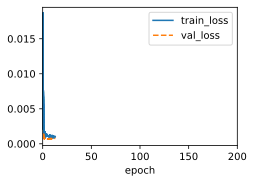

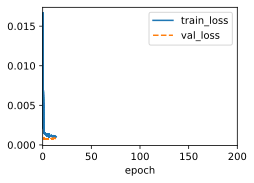

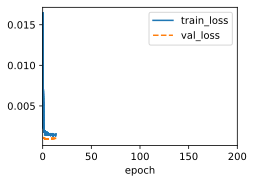

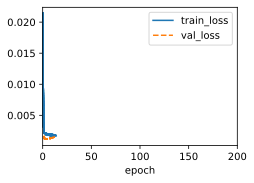

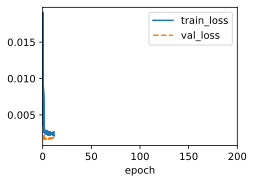

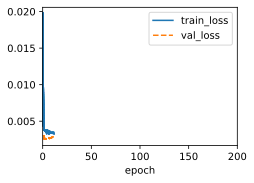

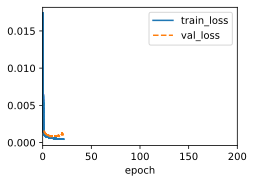

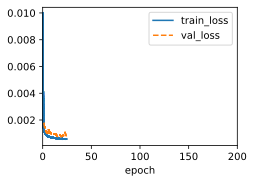

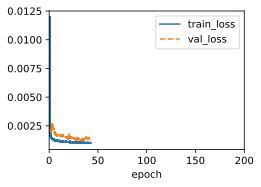

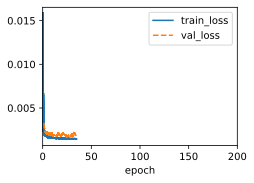

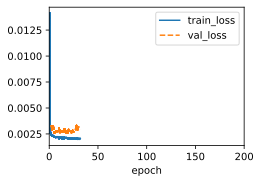

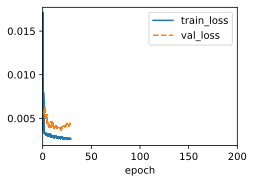

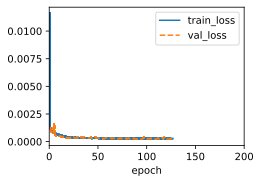

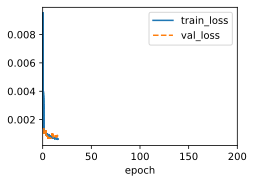

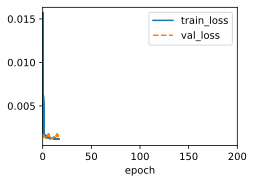

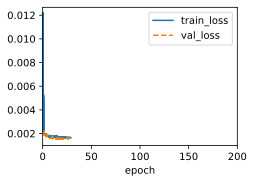

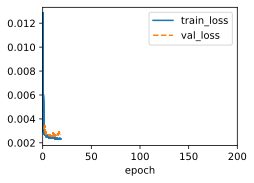

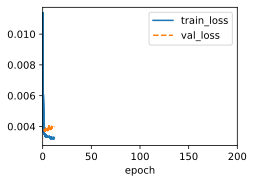

In [27]:
# Train the LSTM models for each water quality variable and forecast horizon
for target in targets:
    print("\n----------------------------------------------------------------")
    print("----------------------------------------------------------------")
    print("----------------------------------------------------------------")
    print(f"NOW TRAINING TO PREDICT {target}".upper())
    # Obtain the name of the target water quality variable by splitting string on underscores
    var_name = target.split("_")[0] # returns "ammonium", "oxygen", or "temperature"
    # Instantiate the LSTM class with optimised hyperparameters
    lstm = bchf.LSTM(
        num_inputs=X_train.shape[1],
        num_hiddens=int(hpo_target_mapping[var_name]["config_num_hiddens"]), # uses the number of hidden units directly from HPO pipeline
        num_layers=int(hpo_target_mapping[var_name]["config_num_layers"]), # uses the number of layers directly from HPO pipeline
        dropout=float(hpo_target_mapping[var_name]["config_dropout"]) # uses the dropout regularisation rate directly from HPO pipeline
        )
    # Instantiate the model for predicting water quality time series
    lstm_water_quality_model = bchf.RNNWQ(
        rnn=lstm,
        out_features=1, # single-target prediction
        lr=float(hpo_target_mapping[var_name]["config_learning_rate"]), # uses the learning rate directly from HPO pipeline
        weight_decay=float(hpo_target_mapping[var_name]["config_weight_decay"]) # uses the weight decay regularisation rate directly from HPO pipeline
        )
    # Instantiate the trainer for predicting water quality time series
    trainer = bchf.Trainer(max_epochs=200,
                           num_gpus=1,
                           gradient_clip_val=1,
                           early_stopping=True,
                           patience=10,
                           min_delta=0.0,
                           restore_best_params=True)
    # Fit the ammonium model to the time series data
    trainer.fit(lstm_water_quality_model, dataloader_dict[target])
    # Add the trained LSTM water quality model to the dictionary of models
    lstm_model_dict[target] = lstm_water_quality_model

In [30]:
# Save the state dictionaries of LSTM water quality model parameters
for target in targets:
    torch.save(lstm_model_dict[target].state_dict(), f"TILL_HAREHOPE_E_202202_{target}_state_dict.pth")